In [17]:
import numpy as np
import pandas as pd
from numpy import nan as NA
import matplotlib.pyplot as plt
from numpy.random import randn
import random
import seaborn as sns
import csv
from sklearn.linear_model import LinearRegression

Loading and Inspecting Key Columns of the World Population Dataset

In [18]:
x = pd.read_csv("world_population.csv")
print('columns = \n',x.columns)
print()
print('rank = \n',x['Rank'].head(5))   #ranks
print()
print('CCA3 = \n',x['CCA3'].head(5))   #abbreviation مخفف
print()
print('Country/Territory = \n',x['Country/Territory'].head(5))
print()
print('Capital= \n',x['Capital'].head(5))
print()
print('2022 Population = \n',x['2022 Population'].sort_values())
print()
print('Growth Rate = \n',x['Growth Rate'].head(5))
print()
print('World Population Percentage = \n',x['World Population Percentage'].head(5))
colors = sns.color_palette('tab10')[0:10]
#'Set3'
#'pastel'
#'tab10'

columns = 
 Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020 Population', '2015 Population',
       '2010 Population', '2000 Population', '1990 Population',
       '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)',
       'Growth Rate', 'World Population Percentage'],
      dtype='object')

rank = 
 0     36
1    138
2     34
3    213
4    203
Name: Rank, dtype: int64

CCA3 = 
 0    AFG
1    ALB
2    DZA
3    ASM
4    AND
Name: CCA3, dtype: object

Country/Territory = 
 0       Afghanistan
1           Albania
2           Algeria
3    American Samoa
4           Andorra
Name: Country/Territory, dtype: object

Capital= 
 0               Kabul
1              Tirana
2             Algiers
3           Pago Pago
4    Andorra la Vella
Name: Capital, dtype: object

2022 Population = 
 226           510
209          1871
150          1934
64           3780
137          4390
          ...    
156     235824862
93      2755013

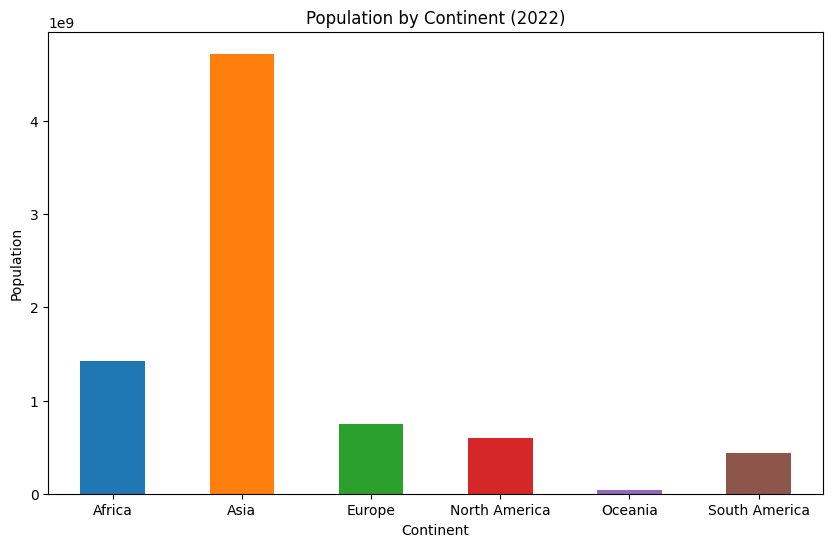

In [19]:
continent_population = x.groupby('Continent')['2022 Population'].sum()
continent_population.plot(kind='bar',figsize=(10,6),rot=0, color = colors)
plt.title('Population by Continent (2022)')
plt.xlabel('Continent')
plt.ylabel('Population')
plt.show()

Pie Chart of Top 10 Most Populated Countries (2022)

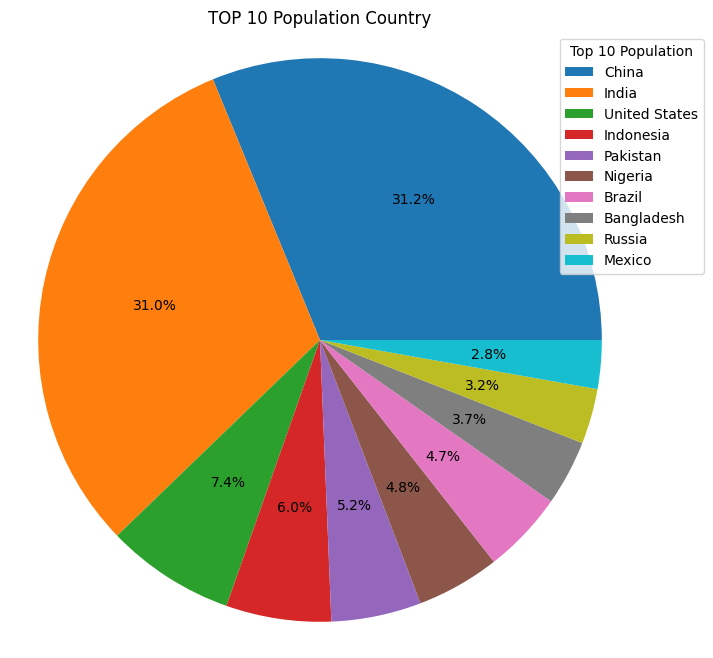

In [20]:
top10 = x.sort_values('2022 Population',ascending=False).head(10)
plt.figure(figsize=(8,8))
wedges , texts , autotexts = plt.pie(top10['2022 Population'],autopct='%1.1f%%',colors=colors)
plt.legend(
    handles=wedges,
    labels=top10['Country/Territory'].tolist(),
    title='Top 10 Population',
    loc='upper right',
    bbox_to_anchor=(1.13, 1)
)
plt.axis('equal')
plt.title('TOP 10 Population Country')
plt.savefig("Pie_Top10_2022", dpi=300, bbox_inches='tight')
plt.show()

South Korea Population Trend (2000–2022)

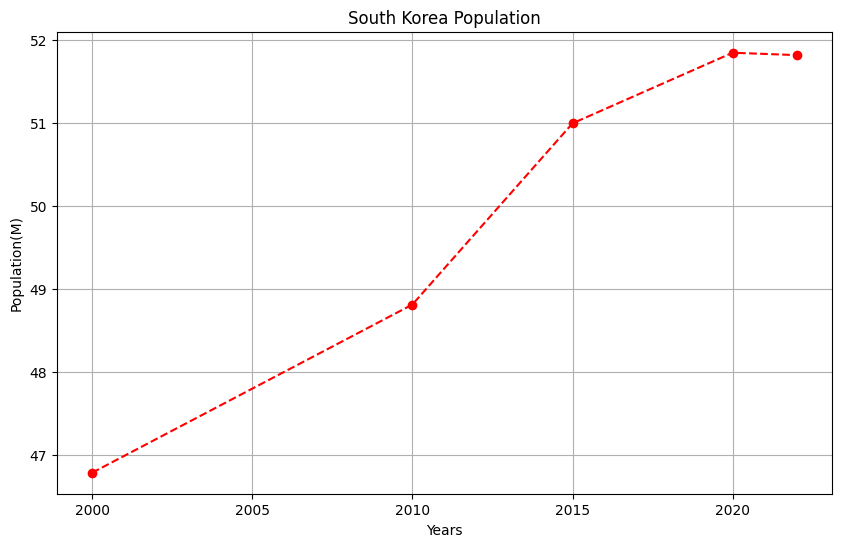

In [21]:
columns = ['2000 Population', '2010 Population', '2015 Population', '2020 Population', '2022 Population']
south_korea = x[x['Country/Territory'] == 'South Korea']
populations = south_korea[columns].values.flatten()
populations_m = populations / 1_000_000
years = [2000,2010,2015,2020,2022]
plt.figure(figsize=(10,6))
plt.plot(years,populations_m , marker = 'o' ,color = 'red' , linestyle = 'dashed')
plt.title('South Korea Population')
plt.xlabel('Years')
plt.ylabel('Population(M)')
plt.grid(True)
plt.savefig("South_Korea_Population", dpi=300, bbox_inches='tight')
plt.show()

Heatmap of Top 10 Densely Populated Countries

columns = 
 Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020 Population', '2015 Population',
       '2010 Population', '2000 Population', '1990 Population',
       '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)',
       'Growth Rate', 'World Population Percentage'],
      dtype='object')



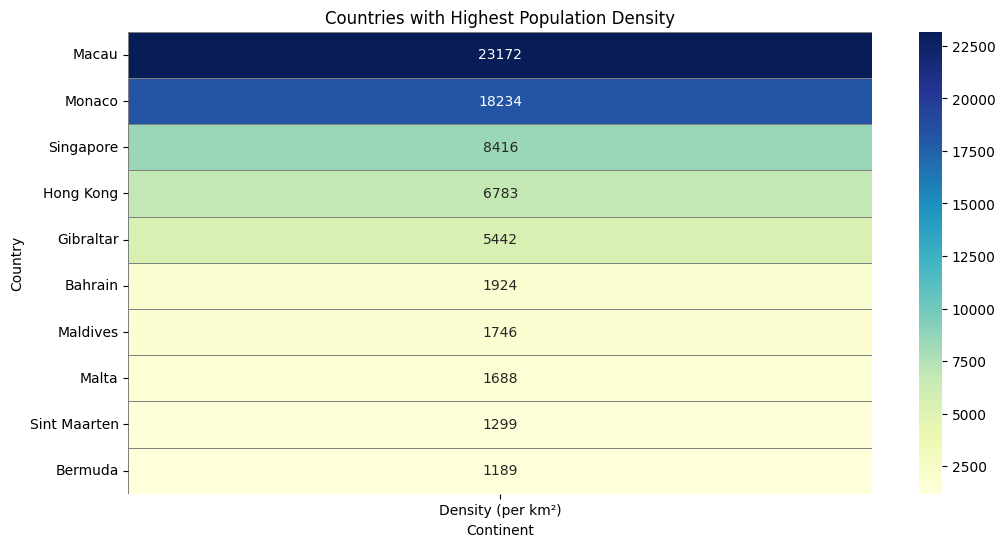

In [22]:
print('columns = \n',x.columns)
print()
top = x.sort_values('Density (per km²)',ascending=False).head(10)
top = top[['Country/Territory','Density (per km²)']].set_index('Country/Territory')
plt.figure(figsize=(12,6))
sns.heatmap(top,cmap='YlGnBu',annot=True , fmt='.0f',linewidths=0.5,linecolor='gray')
plt.title('Countries with Highest Population Density')
plt.xlabel('Continent')
plt.ylabel('Country')
plt.savefig("Density_Heatmap", dpi=300, bbox_inches='tight')
plt.show()

Creating a model to predict

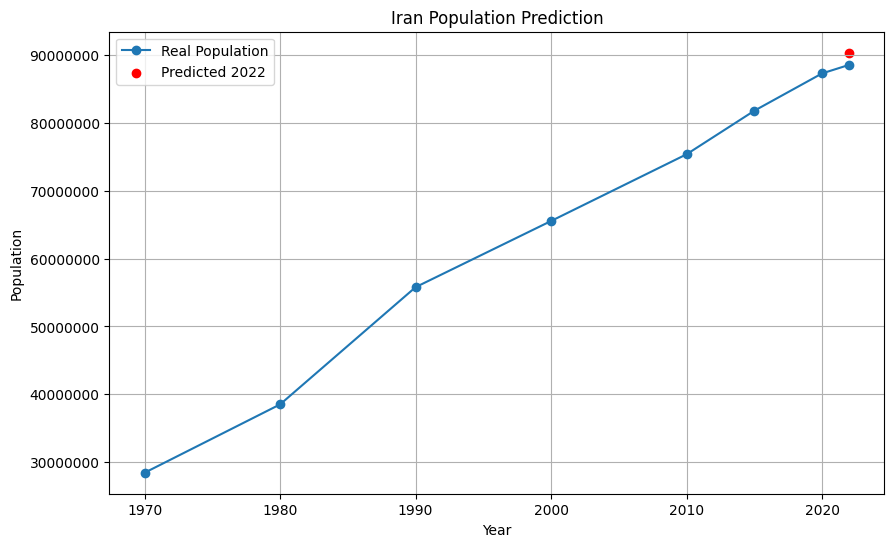

In [28]:
ir = x[x['Country/Territory'] == 'Iran']
years = [1970,1980,1990,2000,2010,2015,2020,2022]
pop = [
    ir['1970 Population'].values[0],
    ir['1980 Population'].values[0],
    ir['1990 Population'].values[0],
    ir['2000 Population'].values[0],
    ir['2010 Population'].values[0],
    ir['2015 Population'].values[0],
    ir['2020 Population'].values[0],
    ir['2022 Population'].values[0]
]
data = pd.DataFrame({'Year' : years , 'Population' : pop})
train = data[data['Year'] < 2022]
x_train = train[['Year']]
y_train = train['Population']

model = LinearRegression()
model.fit(x_train,y_train)
pred_2022 = model.predict(pd.DataFrame({'Year':[2022]}))
real_2022 = data[data['Year'] == 2022]['Population'].values[0]

plt.figure(figsize=(10,6))
plt.ticklabel_format(style='plain', axis='y')
plt.plot(data['Year'],data['Population'],marker = 'o',label ='Real Population')
plt.scatter(2022,pred_2022,color = 'red', label = 'Predicted 2022')
plt.title('Iran Population Prediction')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()
